<a href="https://colab.research.google.com/github/LaviniBastos/FormacaoFlyEducacao-Alura/blob/main/Multiclasses.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classificação: Resolvendo problemas de multiclasse


Uma instituição de ensino superior solicitou que desenvolvêssemos um modelo de Machine Learning (Aprendizado de Máquina) destinado a prever a evasão de estudantes, ou seja, prever se as pessoas estudantes estão propensos a abandonar seu curso ou faculdade antes que isso realmente ocorra.

O objetivo é manter as pessoas estudantes comprometidas e evitar a evasão.

### Contextualizando

Desenvolver um modelo que permita antecipar a desistência antes que ocorra é de grande relevância, pois capacita a instituição a adotar estratégias preventivas.

Nesse sentido, iremos utilizar dados reais de uma instituição de ensino superior em Portugal e importá-los para o Google Colab, dando início ao processo de desenvolvimento deste projeto.

Os dados são reais, provenientes do Instituto Politécnico de Portalegre, uma instituição de ensino superior em Portugal.

Este conjunto de dados abrange uma ampla gama de informações, incluindo dados demográficos, socioeconômicos e macroeconômicos, dados capturados no momento da matrícula dos estudantes, bem como no final dos primeiros e segundos semestres.

As fontes de dados são diversas, incluindo fontes internas da instituição, como o Sistema de Gestão Acadêmica (AMS) e o Sistema de Apoio à Atividade Docente (PAE), bem como dados da Direção Geral do Ensino Superior (DGES) relacionados ao ingresso no ensino superior por meio do Concurso Nacional de Acesso ao Ensino Superior (CNAES). Além disso, dados macroeconômicos foram incorporados a partir da Base de Dados Portugal Contemporâneo (PORDATA).

Estes dados são representativos dos registros de estudantes matriculados no período entre os anos letivos de 2008/2009 (após a implementação do Processo de Bolonha no ensino superior europeu) e 2018/2019. Eles abrangem 17 cursos de graduação em diversas áreas do conhecimento, como agronomia, design, educação, enfermagem, jornalismo, gestão, serviço social e tecnologias.

In [ ]:
import pandas as pd

In [ ]:
dados = pd.read_csv('/content/dados_estudantes.csv')

- Analisando como os dados estão dispostos e distribuidos.

In [ ]:
dados

,Estado civil,Migração,Sexo,Idade na matrícula,Estrangeiro,Necessidades educacionais especiais,Devedor,Taxas de matrícula em dia,Bolsista,Taxa de desemprego,Taxa de inflação,PIB,Curso,Período,Qualificação prévia,disciplinas 1º semestre (creditadas),disciplinas 1º semestre (matriculadas),disciplinas 1º semestre (avaliações),disciplinas 1º semestre (aprovadas),disciplinas 1º semestre (notas),disciplinas 1º semestre (sem avaliações),disciplinas 2º semestre (creditadas),disciplinas 2º semestre (matriculadas),disciplinas 2º semestre (avaliações),disciplinas 2º semestre (aprovadas),disciplinas 2º semestre (notas),disciplinas 2º semestre (sem avaliações),Target
0,Solteiro,Sim,Masculino,20,Não,Não,Não,Sim,Não,10.8,1.4,1.74,Animação e Design Multimídia,Diurno,Educação secundária,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,Desistente
1,Solteiro,Sim,Masculino,19,Não,Não,Não,Não,Não,13.9,-0.3,0.79,Turismo,Diurno,Educação secundária,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,Graduado
2,Solteiro,Sim,Masculino,19,Não,Não,Não,Não,Não,10.8,1.4,1.74,Design de Comunicação,Diurno,Educação secundária,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,Desistente
3,Solteiro,Sim,Feminino,20,Não,Não,Não,Sim,Não,9.4,-0.8,-3.12,Jornalismo e Comunicação,Diurno,Educação secundária,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,Graduado
4,Casado,Não,Feminino,45,Não,Não,Não,Sim,Não,13.9,-0.3,0.79,Serviço Social (noturno),Noturno,Educação secundária,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,Graduado
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,Solteiro,Não,Masculino,19,Não,Não,Não,Sim,Não,15.5,2.8,-4.06,Jornalismo e Comunicação,Diurno,Educação secundária,0,6,7,5,13.600000,0,0,6,8,5,12.666667,0,Graduado
4420,Solteiro,Sim,Feminino,18,Sim,Não,Sim,Não,Não,11.1,0.6,2.02,Jornalismo e Comunicação,Diurno,Educação secundária,0,6,6,6,12.000000,0,0,6,6,2,11.000000,0,Desistente
4421,Solteiro,Sim,Feminino,30,Não,Não,Não,Sim,Sim,13.9,-0.3,0.79,Enfermagem,Diurno,Educação secundária,0,7,8,7,14.912500,0,0,8,9,1,13.500000,0,Desistente
4422,Solteiro,Sim,Feminino,20,Não,Não,Não,Sim,Sim,9.4,-0.8,-3.12,Gestão,Diurno,Educação secundária,0,5,5,5,13.800000,0,0,5,6,5,12.000000,0,Graduado


- Analisando todas as colunas, seus tipos e aqui conseguimos verificar se existem valores nulos.

In [ ]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 28 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Estado civil                              4424 non-null   object 
 1   Migração                                  4424 non-null   object 
 2   Sexo                                      4424 non-null   object 
 3   Idade na matrícula                        4424 non-null   int64  
 4   Estrangeiro                               4424 non-null   object 
 5   Necessidades educacionais especiais       4424 non-null   object 
 6   Devedor                                   4424 non-null   object 
 7   Taxas de matrícula em dia                 4424 non-null   object 
 8   Bolsista                                  4424 non-null   object 
 9   Taxa de desemprego                        4424 non-null   float64
 10  Taxa de inflação                    

- Quais categorias temos na coluna Target, que é a variável importante nesse caso para basear a análise das outras colunas.

In [ ]:
dados['Target'].unique()

array(['Desistente', 'Graduado', 'Matriculado'], dtype=object)

- Aplicando o filtro que sumariza as colunas numéricas trazendo informações estatistico sobre como os dados estão distribuidos pela base de dados.

In [ ]:
dados.describe()

,Idade na matrícula,Taxa de desemprego,Taxa de inflação,PIB,disciplinas 1º semestre (creditadas),disciplinas 1º semestre (matriculadas),disciplinas 1º semestre (avaliações),disciplinas 1º semestre (aprovadas),disciplinas 1º semestre (notas),disciplinas 1º semestre (sem avaliações),disciplinas 2º semestre (creditadas),disciplinas 2º semestre (matriculadas),disciplinas 2º semestre (avaliações),disciplinas 2º semestre (aprovadas),disciplinas 2º semestre (notas),disciplinas 2º semestre (sem avaliações)
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,23.265145,11.566139,1.228029,0.001969,0.709991,6.270570,8.299051,4.706600,10.640822,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316
std,7.587816,2.663850,1.382711,2.269935,2.360507,2.480178,4.179106,3.094238,4.843663,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774
min,17.000000,7.600000,-0.800000,-4.060000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,9.400000,0.300000,-1.700000,0.000000,5.000000,6.000000,3.000000,11.000000,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000
50%,20.000000,11.100000,1.400000,0.320000,0.000000,6.000000,8.000000,5.000000,12.285714,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000
75%,25.000000,13.900000,2.600000,1.790000,0.000000,7.000000,10.000000,6.000000,13.400000,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000
max,70.000000,16.200000,3.700000,3.510000,20.000000,26.000000,45.000000,26.000000,18.875000,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000


- Explorando os dados demográficos de cada estudante

In [ ]:
dados['Estado civil'].value_counts(normalize = True)*100

,proportion
Estado civil,
Solteiro,88.584991
Casado,8.566908
Divorciado,2.056962
União Estável,0.565099
Legalmente Separado,0.135624
Viúvo,0.090416


- Importando as duas principais bibliotecas de visualização para entender em qual faixa etária os dados estão distribuidos

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

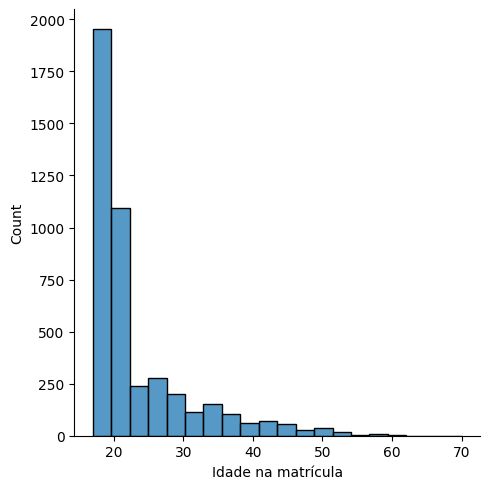

In [ ]:
sns.displot(dados['Idade na matrícula'], bins=20)
plt.show()

- Como será que as idades estão sendo distribuidas pelas classes da variável target? Podemos analisar isso também através das visualizações e separar esse numéros pela classe. Podemos usar uma cor para cada classe dessa forma conseguimos ver com mais precisão

In [ ]:
color_dict = {'Desistente': '#e34c42', 'Graduado': '#4dc471', 'Matriculado': '#3b71db'}
sns.set_palette(list(color_dict.values()))

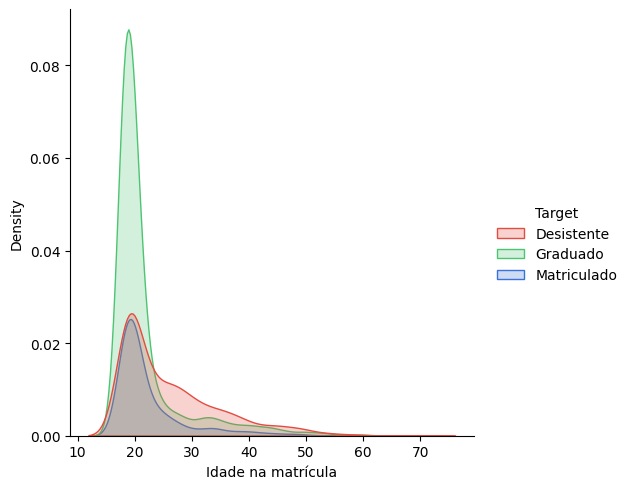

In [ ]:
sns.displot(data=dados, x='Idade na matrícula', hue='Target', kind = 'kde', fill = True)
plt.show()

- Podemos analisar também a distribuição dos dados em relação aos estudantes estrangeiros.

In [ ]:
dados['Estrangeiro'].value_counts(normalize = True)*100

,proportion
Estrangeiro,
Não,97.513562
Sim,2.486438


- Fazemos o mesmo para os gêneros (sexo).

In [ ]:
dados['Sexo'].value_counts(normalize = True)*100

,proportion
Sexo,
Feminino,64.82821
Masculino,35.17179


- A distribuição de dados entre os gêneros masculino e feminino é:
  - 65% Feminino
  - 35% Masculino

- Trazendo esses resultado para uma visualização e correlacionando com o Target

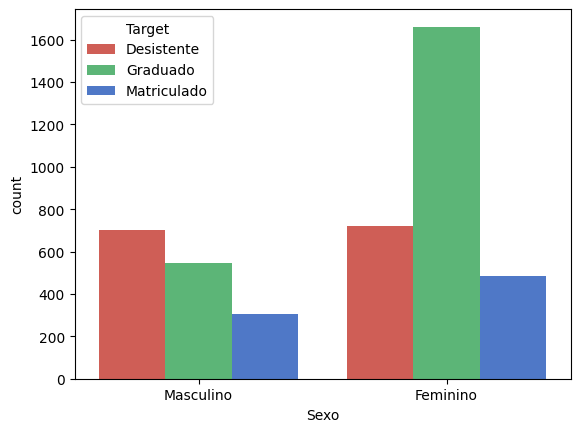

In [ ]:
sns.countplot(x='Sexo', hue='Target', data=dados)
plt.show()

- Existe ali claramente uma diferença bem grande entre os generos: Temos uma quantidade grande de mulheres na graduação e a grande maioria realmente se formam, enquanto os homens entram menos na faculdade e também desistem muito mais.

- Analisando dados econômicos pela coluna "Devedor"

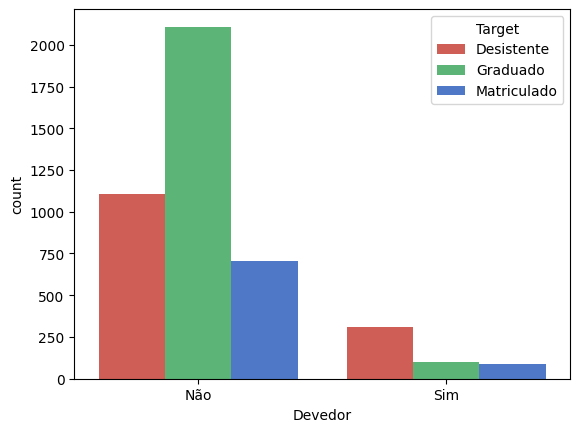

In [ ]:
sns.countplot(x='Devedor', hue='Target', data=dados)
plt.show()

O recurso financeiro pode ser e pelos dados conseguimos ver que é um dos motivos das pessoas estarem desistindo dos cursos

- Analisando os dados econômicos pela coluna 'Taxas de Matricula em dia"

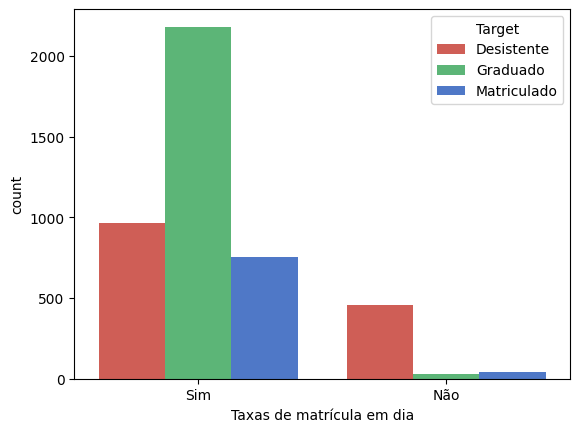

In [ ]:
sns.countplot(x='Taxas de matrícula em dia', hue='Target', data=dados)
plt.show()

- Analisando a partir da coluna "Bolsistas", como os bolsistas estão em relação ao target.

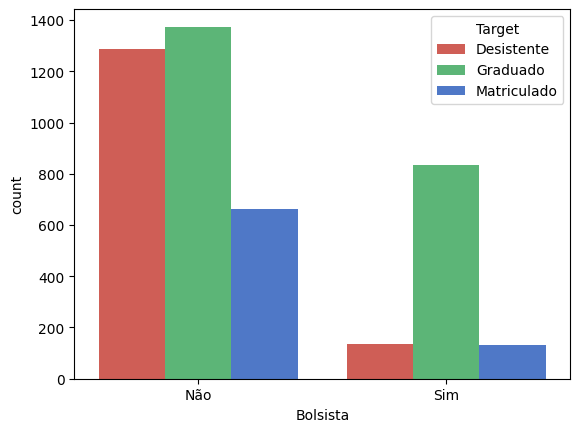

In [ ]:
sns.countplot(x='Bolsista', hue='Target', data=dados)
plt.show()

- Bolsistas desistem menos e se graduam mais, a questão econômica está muito relacionada a evasão escolar

- Criando uma visualização para ver a porcentagem de desistência para cada curso

In [ ]:
import plotly.express as px

In [ ]:
contagem = dados.groupby(['Curso', 'Target']).size().reset_index(name='Contagem')
contagem['Porcentagem'] = contagem.groupby('Curso')['Contagem'].transform(lambda x: (x/x.sum())*100)

fig = px.bar(contagem, y='Curso', x='Porcentagem', color='Target', orientation='h',
             color_discrete_map={'Desistente': '#e34c42', 'Graduado': '#4dc471', 'Matriculado': '#3b71db'})

fig.show()

- Alguns cursos noturnos possuem mais evasão que o mesmo curso no periodo da manhã ou tarde

- Analisando agora a relação entre as notas baixas com a desistência doas cursos

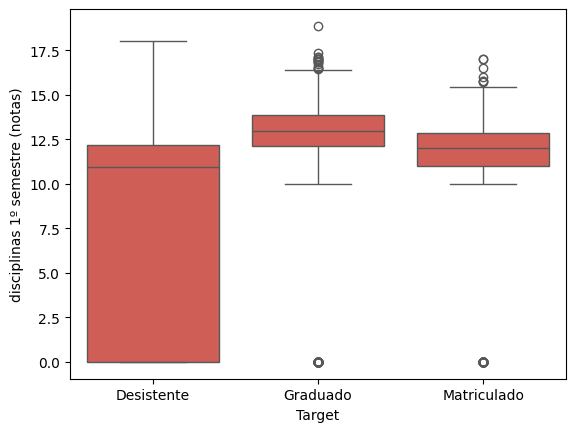

In [ ]:
sns.boxplot(x='Target', y='disciplinas 1º semestre (notas)', data=dados)
plt.show()

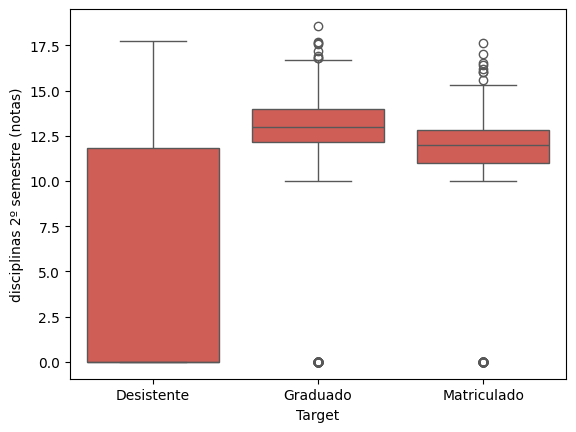

In [ ]:
sns.boxplot(x='Target', y='disciplinas 2º semestre (notas)', data=dados)
plt.show()

- quantos % temos em cada uma dessas categorias

In [ ]:
dados['Target'].value_counts(normalize=True)*100

,proportion
Target,
Graduado,49.932188
Desistente,32.120253
Matriculado,17.947559


## Ampliando a exploração dos dados

Analisar a relação da variável target com as colunas:

- Migração
- Necessidades educacionais especiais
- Taxa de desemprego
- Taxa de inflação
- PIB
- Qualificação prévia

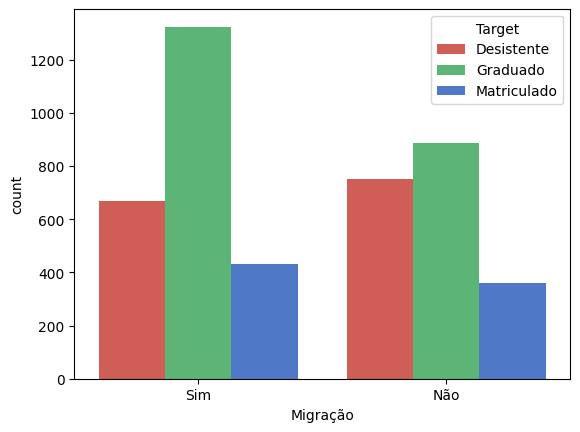

In [ ]:
sns.countplot(x='Migração', hue='Target', data=dados)
plt.show()

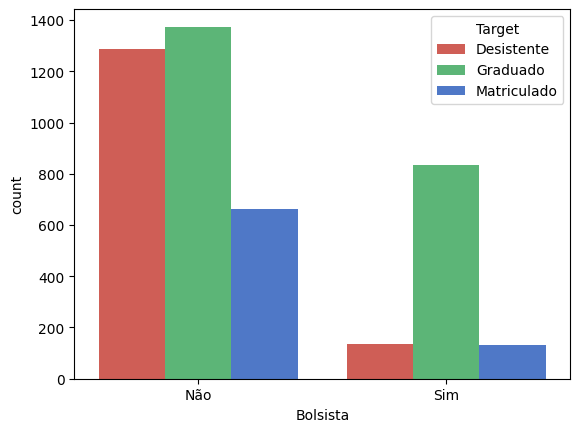

In [ ]:
sns.countplot(x='Bolsista', hue='Target', data=dados)
plt.show()

## Preparando os dados para o modelo de machine Learning

-- Transformar os dados categóricos em valores numéricos

In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
colunas_categoricas =  ['Migração', 'Sexo', 'Estrangeiro', 'Necessidades educacionais especiais', 'Devedor', 'Taxas de matrícula em dia', 'Bolsista', 'Período', 'Estado civil', 'Qualificação prévia' ]

In [ ]:
encoder = OneHotEncoder(drop = 'if_binary')

df_categorico = dados[colunas_categoricas]

df_encoded = pd.DataFrame(encoder.fit_transform(df_categorico).toarray(),
                          columns=encoder.get_feature_names_out(colunas_categoricas))


df_final = pd.concat([dados.drop(colunas_categoricas, axis=1), df_encoded], axis=1)

df_final = df_final.drop(['Curso'], axis = 1)

In [ ]:
df_final

,Idade na matrícula,Taxa de desemprego,Taxa de inflação,PIB,disciplinas 1º semestre (creditadas),disciplinas 1º semestre (matriculadas),disciplinas 1º semestre (avaliações),disciplinas 1º semestre (aprovadas),disciplinas 1º semestre (notas),disciplinas 1º semestre (sem avaliações),disciplinas 2º semestre (creditadas),disciplinas 2º semestre (matriculadas),disciplinas 2º semestre (avaliações),disciplinas 2º semestre (aprovadas),disciplinas 2º semestre (notas),disciplinas 2º semestre (sem avaliações),Target,Migração_Sim,Sexo_Masculino,Estrangeiro_Sim,Necessidades educacionais especiais_Sim,Devedor_Sim,Taxas de matrícula em dia_Sim,Bolsista_Sim,Período_Noturno,Estado civil_Casado,Estado civil_Divorciado,Estado civil_Legalmente Separado,Estado civil_Solteiro,Estado civil_União Estável,Estado civil_Viúvo,Qualificação prévia_10º ano de escolaridade,Qualificação prévia_10º ano de escolaridade - não concluído,Qualificação prévia_11º ano de escolaridade - não concluído,Qualificação prévia_12º ano de escolaridade - não concluído,Qualificação prévia_Curso de especialização tecnológica,Qualificação prévia_Curso técnico superior profissional,Qualificação prévia_Educação básica 2º ciclo (6º/7º/8º ano) ou equivalente,Qualificação prévia_Educação básica 3º ciclo (9º/10º/11º ano) ou equivalente,Qualificação prévia_Educação secundária,Qualificação prévia_Educação superior - bacharelado,Qualificação prévia_Educação superior - doutorado,Qualificação prévia_Educação superior - licenciatura,Qualificação prévia_Educação superior - licenciatura (1º ciclo),Qualificação prévia_Educação superior - mestrado,Qualificação prévia_Educação superior - mestrado (2º ciclo),Qualificação prévia_Frequência de educação superior,Qualificação prévia_Outro - 11º ano de escolaridade
0,20,10.8,1.4,1.74,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,Desistente,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,19,13.9,-0.3,0.79,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,Graduado,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,19,10.8,1.4,1.74,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,Desistente,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,20,9.4,-0.8,-3.12,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,Graduado,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,45,13.9,-0.3,0.79,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,Graduado,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,19,15.5,2.8,-4.06,0,6,7,5,13.600000,0,0,6,8,5,12.666667,0,Graduado,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4420,18,11.1,0.6,2.02,0,6,6,6,12.000000,0,0,6,6,2,11.000000,0,Desistente,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4421,30,13.9,-0.3,0.79,0,7,8,7,14.912500,0,0,8,9,1,13.500000,0,Desistente,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4422,20,9.4,-0.8,-3.12,0,5,5,5,13.800000,0,0,5,6,5,12.000000,0,Graduado,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Criando as variáveis x e y

In [ ]:
# x = todas as váriáveis exceto a variável target
X = df_final.drop('Target', axis = 1)
y = df_final['Target']

In [ ]:
from sklearn.model_selection import train_test_split


In [ ]:
## Separando os dados em treino / validação e teste

X, X_teste, y, y_teste = train_test_split(X, y, test_size=0.15, stratify=y, random_state=0)
X_treino, X_val, y_treino, y_val = train_test_split(X, y, stratify=y, random_state=0)


## Agora que os dados estão separados, temos que escolher qual algoritmo iremos utilizar

-- Existem vários disponíveis no sklearn mas aqui focaremos no Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
modelo_rf = RandomForestClassifier(random_state=0) ## <-- Instânciando o algoritmo

modelo_rf.fit(X_treino, y_treino) ## <--- Treinando o modelo
y_pred = modelo_rf.predict(X_val) # <--- Ele vai prever com os dados de validação

## Medir a acurácia: O quanto o modelo tá acertando, tanto nos dados de treino quanto no de validação
print(f'Acurácia Treino: {modelo_rf.score(X_treino, y_treino)}')
print(f'Acurácia Validação: {modelo_rf.score(X_val, y_val)}')

Acurácia Treino: 0.9975177304964539
Acurácia Validação: 0.7702127659574468


Acurácia nos dados treino chegando a quase 1.0 significa = overfiting, ele está praticamente decorando os dados

Para melhorar isso podmeos usar um parametro onde aárvore de decisao se aprofunda ainda mais nos dados, entao podemos definir a profundidade máxima dessa árvore.

In [ ]:
modelo_rf = RandomForestClassifier(random_state=0, max_depth=10 ) ## <-- Instânciando o algoritmo

modelo_rf.fit(X_treino, y_treino) ## <--- Treinando o modelo
y_pred = modelo_rf.predict(X_val) # <--- Ele vai prever com os dados de validação

## Medir a acurácia: O quanto o modelo tá acertando, tanto nos dados de treino quanto no de validação
print(f'Acurácia Treino: {modelo_rf.score(X_treino, y_treino)}')
print(f'Acurácia Validação: {modelo_rf.score(X_val, y_val)}')

Acurácia Treino: 0.8939716312056738
Acurácia Validação: 0.7648936170212766


O Ajuste de profundidade foi feito, e agora a árvore teve uma queda na sua acurácia. Mas existem também outras classes que definem se um modelo está performando bem

- Matriz de confusão

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
matriz_confusao = confusion_matrix(y_val, y_pred)

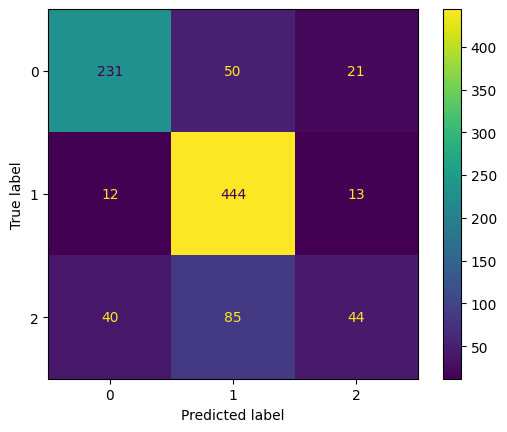

In [ ]:
visualizacao = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao)
visualizacao.plot();

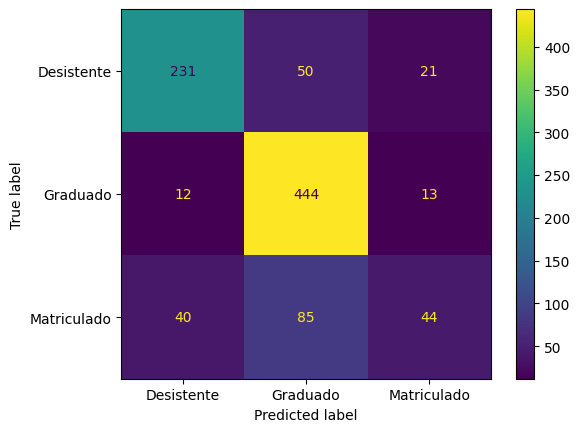

In [ ]:
visualizacao = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao, display_labels=modelo_rf.classes_)
visualizacao.plot();

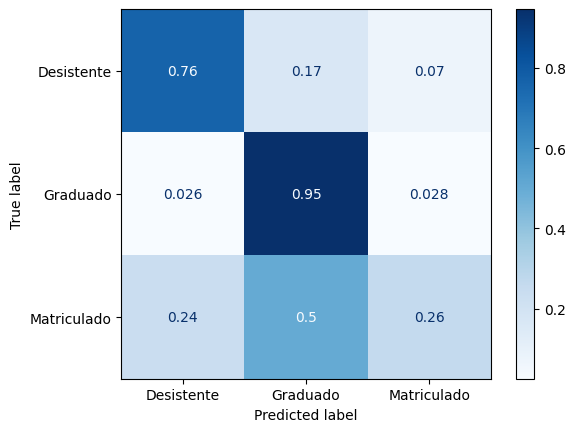

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_val, y_pred, normalize='true', cmap='Blues');

### Relatório de métricas

In [ ]:
from sklearn.metrics import classification_report


In [ ]:
report = classification_report(y_val, y_pred)

print('Relatório de classificação:\n', report)

Relatório de classificação:
               precision    recall  f1-score   support

  Desistente       0.82      0.76      0.79       302
    Graduado       0.77      0.95      0.85       469
 Matriculado       0.56      0.26      0.36       169

    accuracy                           0.76       940
   macro avg       0.72      0.66      0.66       940
weighted avg       0.75      0.76      0.74       940



A metricas ficaram desbalanceadas para "Matriculado" porque simplesmente existe poucos dados sobre.

Vamos Balancear os dados com a técnica de "super amostragem"
Aumentar a quantidade de amostras nas classes minoritarias

In [ ]:
y_treino.value_counts()

,count
Target,
Graduado,1408
Desistente,906
Matriculado,506


In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
oversample = SMOTE(random_state=0)
X_balanceado, y_balanceado = oversample.fit_resample(X_treino, y_treino)

In [ ]:
y_balanceado.value_counts()

,count
Target,
Desistente,1408
Graduado,1408
Matriculado,1408


In [ ]:
modelo = RandomForestClassifier(random_state=0, max_depth = 10)
modelo.fit(X_balanceado, y_balanceado)
y_pred = modelo.predict(X_val)

### - Verificando como o modelo ficou depois do balanceamento nos dados

              precision    recall  f1-score   support

  Desistente       0.86      0.72      0.78       302
    Graduado       0.82      0.87      0.84       469
 Matriculado       0.49      0.55      0.52       169

    accuracy                           0.76       940
   macro avg       0.72      0.71      0.71       940
weighted avg       0.77      0.76      0.76       940



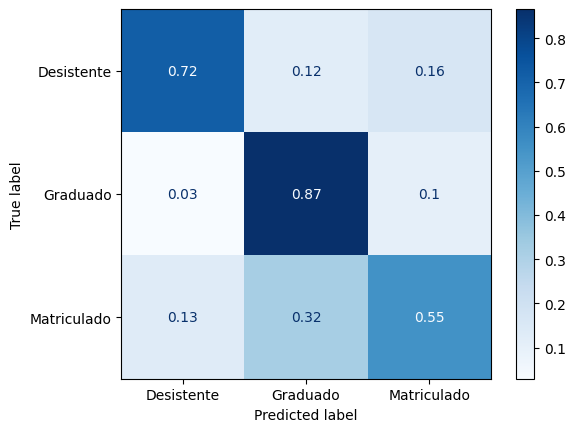

In [ ]:
print(classification_report(y_val, y_pred))
ConfusionMatrixDisplay.from_predictions(y_val, y_pred, normalize='true', cmap='Blues')

- Neste caso a precisão caiu, isso é chamado de **Trade off entre a precisão e o Recall **
Quando melhoramos uma coisa pioramos outra

### Validando o modelo de forma mais robusta

Validação cruzada: dividindo os dados de treino em várias partes

In [ ]:
from imblearn.pipeline import Pipeline as imbpipeline

In [ ]:
modelo = RandomForestClassifier(max_depth = 10)
pipeline = imbpipeline([('oversample', SMOTE()), ('floresta', modelo)])

In [ ]:
from sklearn.model_selection import cross_validate, StratifiedKFold

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
vc_resultados = cross_validate(pipeline, X, y, cv=skf, scoring='recall_weighted')
vc_resultados['test_score']

array([0.76728723, 0.73005319, 0.73803191, 0.75132979, 0.75398936])

In [ ]:
## Definindo um intervalo de confiança

media = vc_resultados['test_score'].mean()
desvio_padrao = vc_resultados['test_score'].std()

print(f'Intervalo de confiança: [{media - 2 * desvio_padrao}, {min(media + 2 * desvio_padrao, 1.0)}]')

Intervalo de confiança: [0.7222105157298851, 0.7740660800147957]


### Testando o modelo com dados que ele nunca viu

              precision    recall  f1-score   support

  Desistente       0.87      0.75      0.80       213
    Graduado       0.82      0.84      0.83       332
 Matriculado       0.46      0.55      0.50       119

    accuracy                           0.76       664
   macro avg       0.72      0.71      0.71       664
weighted avg       0.77      0.76      0.76       664



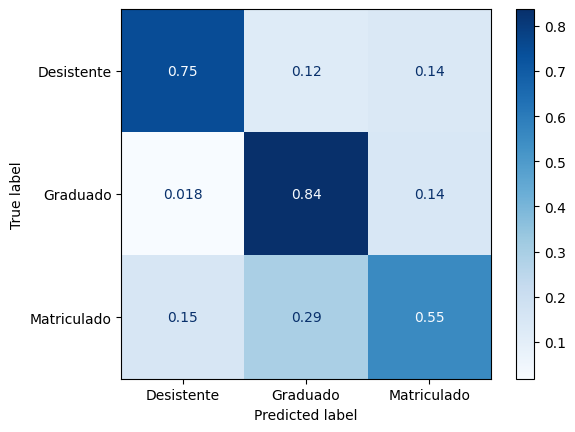

In [ ]:
oversample = SMOTE(random_state=0)
X_balanceado, y_balanceado = oversample.fit_resample(X, y)
modelo = RandomForestClassifier(random_state=0, max_depth = 10)
modelo.fit(X_balanceado, y_balanceado)
y_pred = modelo.predict(X_teste)

print(classification_report(y_teste, y_pred))
ConfusionMatrixDisplay.from_predictions(y_teste, y_pred, normalize='true', cmap='Blues');